https://chatgpt.com/share/68ef49f4-4e28-8009-a389-ce6013f9296f
https://chatgpt.com/c/68ee7527-9720-8331-8c97-d8b80c8723be

In [10]:
# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

import pickle


# If you used Fourier / regressors in class:
from patsy import dmatrix
# (or other functions from your Fourier / embedding notebooks)


In [11]:

# === Load data ===
# Assuming hotels.pk is a pickle file in your Google Drive or working directory

with open("hotels.pk", "rb") as f:
    df = pickle.load(f)


/tmp/ipykernel_79225/3585814959.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


In [12]:
df.head()

,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,NewYork,2.442363e+06,13063.675000,81.991307
2013-01-02,NewYork,2.018559e+06,13069.608539,82.028548
2013-01-03,NewYork,1.927676e+06,13069.608539,82.028548
2013-01-04,NewYork,1.781664e+06,12653.271887,79.415502
2013-01-05,NewYork,1.824994e+06,12827.322364,80.507892


In [13]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\n" + "="*50)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of missing data: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

# Missing values by location (if applicable)
if 'Location' in df.columns:
    print("\n" + "="*50)
    print("\nMissing values by Location:")
    print(df.groupby('Location').apply(lambda x: x.isnull().sum()))

Missing values per column:
Location     0
Revenue      0
Demand       0
Occupancy    0
dtype: int64


Total missing values: 0
Percentage of missing data: 0.00%


Missing values by Location:
            Location  Revenue  Demand  Occupancy
Location                                        
Atlanta            0        0       0          0
Boston             0        0       0          0
Chicago            0        0       0          0
Dallas             0        0       0          0
LosAngeles         0        0       0          0
NewYork            0        0       0          0
Orlando            0        0       0          0
Washington         0        0       0          0


/tmp/ipykernel_79225/1373022430.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('Location').apply(lambda x: x.isnull().sum()))


In [14]:
# Inspect basic info
print(df.head())
print(df.info())
print(df['Location'].unique())

# Filter for one city
CITY = "Boston"
df_city = df[df['Location'] == CITY].copy()

# Use index (already DateTimeIndex)
df_city.index = pd.to_datetime(df_city.index)

# Restrict date range
df_city = df_city.loc[:"2020-01-01"]

# Reindex daily and interpolate
all_idx = pd.date_range(start=df_city.index.min(), end=df_city.index.max(), freq="D")
df_city = df_city.reindex(all_idx)
df_city['Revenue'] = df_city['Revenue'].interpolate(method='time')


           Location       Revenue        Demand  Occupancy
Date                                                      
2013-01-01  NewYork  2.442363e+06  13063.675000  81.991307
2013-01-02  NewYork  2.018559e+06  13069.608539  82.028548
2013-01-03  NewYork  1.927676e+06  13069.608539  82.028548
2013-01-04  NewYork  1.781664e+06  12653.271887  79.415502
2013-01-05  NewYork  1.824994e+06  12827.322364  80.507892
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23254 entries, 2013-01-01 to 2020-10-31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   23254 non-null  object 
 1   Revenue    23254 non-null  float64
 2   Demand     23254 non-null  float64
 3   Occupancy  23254 non-null  float64
dtypes: float64(3), object(1)
memory usage: 908.4+ KB
None
['NewYork' 'Orlando' 'Chicago' 'LosAngeles' 'Washington' 'Atlanta'
 'Dallas' 'Boston']


In [15]:
print(df_city.index.min(), "→", df_city.index.max())

2013-01-01 00:00:00 → 2020-01-01 00:00:00


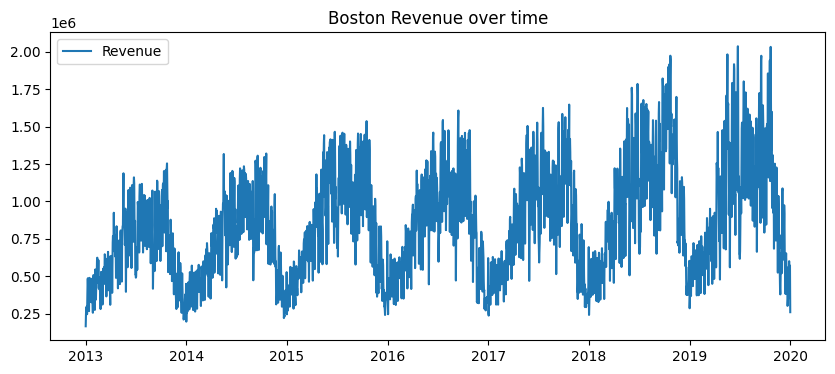

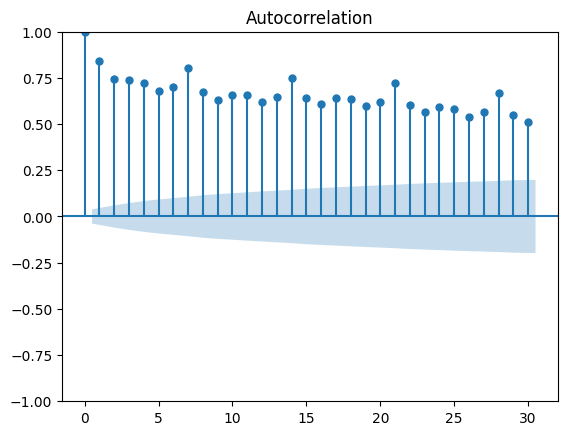

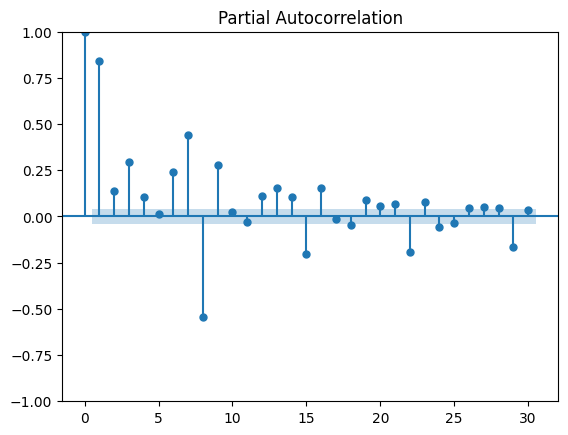

ADF test for Revenue:
  Test statistic: -3.068400879340803
  p-value: 0.028981774418438168
  # lags used: 27
  # observations: 2529
    critical 1%: -3.432938355012086
    critical 5%: -2.8626835272597217
    critical 10%: -2.567378742868999

Mean revenue by weekday:
weekday
0    865033.487404
1    996598.471983
2    983319.684875
3    837554.961151
4    828361.472748
5    922226.389430
6    640944.444414
Name: Revenue, dtype: float64


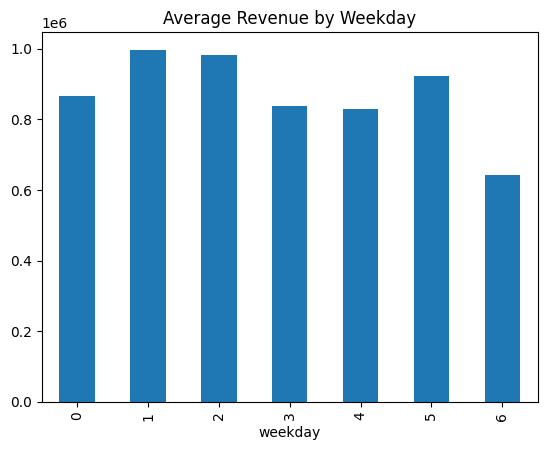

ADF test for Diff(Log Revenue):
  Test statistic: -10.664070470448788
  p-value: 4.332426850127441e-19
  # lags used: 27
  # observations: 2528
    critical 1%: -3.432939379929173
    critical 5%: -2.862683979868293
    critical 10%: -2.5673789838429837



In [16]:

# === EDA / Stationarity check ===

def test_adf(series, title=""):
    result = adfuller(series.dropna())
    print(f"ADF test for {title}:")
    print("  Test statistic:", result[0])
    print("  p-value:", result[1])
    print("  # lags used:", result[2])
    print("  # observations:", result[3])
    for key, val in result[4].items():
        print(f"    critical {key}:", val)
    print()

# Plot revenue over time
plt.figure(figsize=(10,4))
plt.plot(df_city['Revenue'], label="Revenue")
plt.title(f"{CITY} Revenue over time")
plt.legend()
plt.show()

# ACF / PACF
plot_acf(df_city['Revenue'].dropna(), lags=30)
plt.show()
plot_pacf(df_city['Revenue'].dropna(), lags=30)
plt.show()

# Stationarity
test_adf(df_city['Revenue'], title="Revenue")

# You may also look at day-of-week patterns:
df_city['weekday'] = df_city.index.weekday  # Monday=0 ... Sunday=6
dw = df_city.groupby('weekday')['Revenue'].mean()
print("Mean revenue by weekday:")
print(dw)
plt.figure()
dw.plot(kind='bar')
plt.title("Average Revenue by Weekday")
plt.show()

# === Transform / Make stationary if needed ===
# Example: log + difference
df_city['log_rev'] = np.log(df_city['Revenue'].clip(lower=1))  # avoid log(0)
df_city['diff_log_rev'] = df_city['log_rev'].diff()

test_adf(df_city['diff_log_rev'], title="Diff(Log Revenue)")


In [17]:
df_new_york = df[df['Location'] == CITY].copy()
# === Train / Test split ===
train = df_city.loc[: "2019-12-31"].copy()
test = df_new_york.loc["2020-01-01":].copy()


In [18]:
# === Forecasting function (multi-step) ===

def forecast_arima(train_series, steps=7, order=(1,1,1), seasonal_order=None):
    """
    Fit ARIMA (or SARIMA if seasonal_order provided) on train_series,
    and forecast `steps` ahead (out-of-sample).
    Returns forecast (array) and fitted model.
    """
    if seasonal_order:
        # you may want SARIMAX from statsmodels if seasonal part
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        model = SARIMAX(train_series, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        fc = fit.get_forecast(steps=steps)
        return fc.predicted_mean, fit
    else:
        model = ARIMA(train_series, order=order)
        fit = model.fit()
        fc = fit.get_forecast(steps=steps)
        return fc.predicted_mean, fit


In [19]:
# === Evaluate forecasts over test period ===

def evaluate_forecasts(train, test, horizon=7, order=(1,1,1), seasonal_order=None):
    """
    Walk-forward evaluation: on each day in test, forecast horizon days ahead,
    compare to actual. Return metrics per horizon.
    """
    # We assume test is daily contiguous
    errors = {h: [] for h in range(1, horizon+1)}
    forecasts = {h: [] for h in range(1, horizon+1)}
    actuals = {h: [] for h in range(1, horizon+1)}
    
    full = pd.concat([train, test])
    n_train = len(train)
    
    for i in range(n_train, n_train + len(test) - horizon):
        train_end = full.iloc[: i]
        test_window = full.iloc[i: i + horizon]
        train_series = train_end['diff_log_rev'].dropna()  # or whatever series you're forecasting
        fc_values, _ = forecast_arima(train_series, steps=horizon, order=order, seasonal_order=seasonal_order)
        for h in range(1, horizon+1):
            forecasts[h].append(fc_values.iloc[h-1])
            actuals[h].append(test_window['diff_log_rev'].iloc[h-1])
            errors[h].append(fc_values.iloc[h-1] - test_window['diff_log_rev'].iloc[h-1])
    
    # Compute metrics
    metrics = {}
    for h in range(1, horizon+1):
        err = np.array(errors[h])
        metrics[h] = {
            "MAE": np.mean(np.abs(err)),
            "RMSE": np.sqrt(np.mean(err**2))
        }
    return metrics, forecasts, actuals


In [20]:

# === Example run ===

horizon = 7
order = (1,1,1)
# seasonal_order = (1,0,1,7)  # or whatever you might try

metrics, forecasts, actuals = evaluate_forecasts(train, test, horizon=horizon, order=order, seasonal_order=None)

print("Forecast metrics: ")
for h in metrics:
    print(f"{h}-step MAE: {metrics[h]['MAE']:.4f}, RMSE: {metrics[h]['RMSE']:.4f}")

# You’ll want to back-transform forecasts & actuals to revenue scale for plots / interpretation.

# === Plot some forecasts vs actuals (in original scale) ===
# (You’ll need to invert your transformations: cumulative sum of diffs, exponentials, etc.)



/home/fjg/miniconda3/envs/fjgenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/fjg/miniconda3/envs/fjgenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/fjg/miniconda3/envs/fjgenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/fjg/miniconda3/envs/fjgenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/fjg/miniconda3/envs/fjgenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: Val

KeyboardInterrupt: 